# Unit-5 Random Forest

Random Forest is a machine learning algorithm that uses many decision trees to make better predictions. Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression which makes it as ensemble learning technique. This helps in improving accuracy and reducing errors.

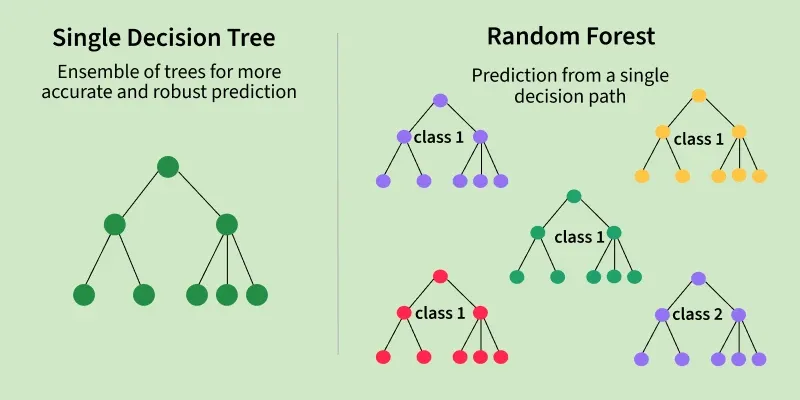!

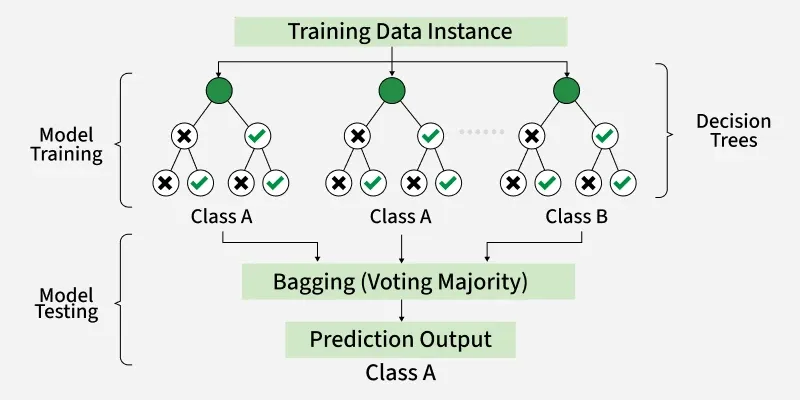

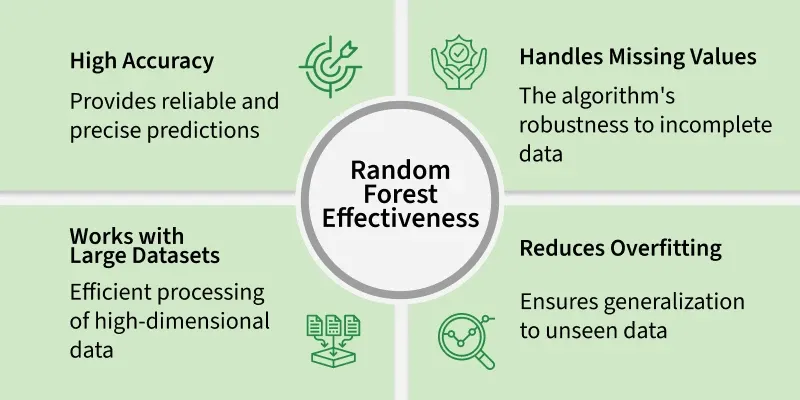

# Working of Random Forest Algorithm
**Create Many Decision Trees:** The algorithm makes many decision trees each using a random part of the data. So every tree is a bit different.

**Pick Random Features:** When building each tree it doesn’t look at all the features (columns) at once. It picks a few at random to decide how to split the data. This helps the trees stay different from each other.

**Each Tree Makes a Prediction:** Every tree gives its own answer or prediction based on what it learned from its part of the data.

**Combine the Predictions:** For classification, the final answer is the category that most trees vote for (majority voting).

**Why It Works Well:** Using random data and features for each tree helps avoid overfitting and makes the overall prediction more accurate and trustworthy.

# Key Features of Random Forest

**Handles Missing Data:** It can work even if some data is missing so you don’t always need to fill in the gaps yourself.

**Shows Feature Importance:** It tells you which features (columns) are most useful for making predictions which helps you understand your data better.

**Works Well with Big and Complex Data:** It can handle large datasets with many features without slowing down or losing accuracy.

**Used for Different Tasks:** You can use it for both classification like predicting types or labels and regression like predicting numbers or amounts.

# Assumptions of Random Forest
**Each tree makes its own decisions:** Every tree in the forest makes its own predictions without relying on others.

**Random parts of the data are used:** Each tree is built using random samples and features to reduce mistakes.

**Enough data is needed:** Sufficient data ensures the trees are different and learn unique patterns and variety.

**Different predictions improve accuracy:** Combining the predictions from different trees leads to a more accurate final result.

# Advantages of Random Forest
- Random Forest provides very accurate predictions even with large datasets.
- Random Forest can handle missing data well without compromising with accuracy.
- It doesn’t require normalization or standardization on dataset.
- When we combine multiple decision trees it reduces the risk of overfitting of the model.

# Limitations of Random Forest
- It can be computationally expensive especially with a large number of trees.
- It’s harder to interpret the model compared to simpler models like decision trees.

# Understanding

Think of a Random Forest like a "Committee of Experts." Instead of asking one person for their opinion (which might be biased), you ask a hundred people and take the majority vote.

### The algorithm uses two main "tricks" to ensure the committee is smart and diverse: Bagging and Feature Randomness.

### 🏗️ Step 1: Bagging (Bootstrap Aggregating)
- The algorithm doesn't give every tree the exact same data. If it did, every tree would be identical and make the same mistakes.

**Bootstrapping:** It takes your original dataset and creates "random samples with replacement."

Imagine you have 100 rows of data. 

- Tree #1 might get rows 1, 5, 20, and 20 again. 

- Tree #2 might get rows 2, 9, 15, and 80.

**Result:** Each tree sees a slightly different version of "reality."

### 🌳 Step 2: Feature Randomness
This is what makes the forest truly "Random." In a normal decision tree, the computer looks at every column (Age, Sex, Fare) and picks the best one to split the data.

In a Random Forest, at every branch, the tree is only allowed to pick from a random subset of features.

**Example:** Even if "Sex" is the strongest predictor, some trees will be forced to ignore it and look at "Age" or "Class" instead.

**Result:** This prevents one dominant feature from overshadowing subtle patterns that other features might hold.

### 🗳️ Step 3: The Majority Vote (Aggregation)
Once the training is done, you have a forest of 100 (or more) independent trees. When you want to predict something (e.g., "Will this passenger survive?"):

Each of the 100 trees looks at the passenger's data.

- Tree 1 says: "Yes"

- Tree 2 says: "No"

- Tree 3 says: "Yes"... and so on.

The algorithm counts the votes. If 80 trees say "Yes" and 20 say "No," the final answer is Yes.

### 🧠 Why is this better than one tree?
The mathematical magic here is the reduction of Variance.

Individual decision trees are prone to overfitting—they are like students who memorize the textbook but fail the actual exam because they don't understand the concepts. Because Random Forest averages many trees that were built on different data and different features, the individual errors (the "noise") cancel each other out, leaving only the "signal" (the truth).

# Implementing Random Forest for Classification Tasks

Here we will predict survival rate of a person in titanic.

- Import libraries like pandas and scikit learn.
- Load the Titanic dataset.
- Remove rows with missing target values ('Survived').
- Select features like class, sex, age, etc and convert 'Sex' to numbers.
- Fill missing age values with the median.
- Split the data into training and testing sets, then train a Random Forest model.
- Predict on test data, check accuracy and print a sample prediction result.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
titanic_data = pd.read_csv('titanic.csv')
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
titanic_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
titanic_data = titanic_data.dropna(subset=['Survived'])
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
X = titanic_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = titanic_data['Survived']

In [6]:
X['Sex'] = X['Sex'].map({'female': 0, 'male': 1})
X['Age'] = X['Age'].fillna(X['Age'].median())

In [9]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.0,1,0,7.2500
1,1,0,38.0,1,0,71.2833
2,3,0,26.0,0,0,7.9250
3,1,0,35.0,1,0,53.1000
4,3,1,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000
887,1,0,19.0,0,0,30.0000
888,3,0,28.0,1,2,23.4500
889,1,1,26.0,0,0,30.0000


In [10]:
print(X.shape)
print(y.shape)

(891, 6)
(891,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


# n_estimators=100
This defines the number of trees in your forest.

**What it does:** You are telling the algorithm to build 100 individual decision trees.

**The Logic:** In a Random Forest, more trees generally lead to a more stable and accurate model because the "average" of 100 opinions is more reliable than the average of 5.

**The Trade-off:**  
- **Pros:** Better performance and less "noise."

- **Cons:** It takes more memory and more time to train. After a certain point (e.g., 500 or 1000 trees), you get "diminishing returns" where adding more trees doesn't actually help accuracy but makes the code slower.

### Why set max_depth in a Random Forest?

**You might wonder:** "If Random Forest is meant to fix overfitting, why do I need to limit the depth?"

**Memory & Speed:** Very deep trees take up a lot of RAM and take longer to train.

**Redundancy:** Often, the 20th split in a tree adds almost zero predictive power compared to the 1st or 2nd split.

**The "Forest" Synergy:** Sometimes, 100 "medium-smart" trees (depth 5-10) perform better and faster than 100 "genius-but-stubborn" trees (depth 50).

#### 🛠️ How to use it

##### Example of a "shallow" forest (good for small datasets or avoiding noise)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

**Pro Tip:** If you aren't sure what depth to use, start with None (the default). 

If you notice your training accuracy is 100% but your testing accuracy is much lower (e.g., 75%), that’s a clear sign you should try setting a max_depth to "reign in" the model.

In [12]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
print(y_pred)

[0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 0 1
 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1]


In [39]:
accuracy = accuracy_score(y_test, y_pred)
# classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
# print("\nClassification Report:\n", classification_rep)

Accuracy: 0.80


In [40]:
sample = X_test.iloc[0:1]
print(sample)
prediction = rf_classifier.predict(sample)
sample_dict = sample.iloc[0].to_dict()
print()
print(f"Sample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")

     Pclass  Sex   Age  SibSp  Parch     Fare
709       3    1  28.0      1      1  15.2458

Sample Passenger: {'Pclass': 3.0, 'Sex': 1.0, 'Age': 28.0, 'SibSp': 1.0, 'Parch': 1.0, 'Fare': 15.2458}
Predicted Survival: Did Not Survive


# New Dataset- Fruit Classification

If you want the absolute simplest dataset to see the logic of a Random Forest without getting lost in hundreds of rows, the Fruit Classification dataset is the winner.

It’s small enough that you can practically draw the trees on a piece of paper.

### 🍎 The Dataset: Fruit Picker
We want to predict if a fruit is an Orange or an Apple based on its physical properties.

### 🌳 How the Forest sees this:
In a Random Forest with, say, 3 trees, the randomness would split the logic like this:

**Tree 1 (Focuses on Texture):** If it's "Bumpy," it's an Orange. If it's "Smooth," it's an Apple.

**Tree 2 (Focuses on Color):** If it's "Orange" or "Yellow," it's an Orange. If it's "Red" or "Green," it's an Apple.

**Tree 3 (Focuses on Weight):** If it's over 165g, it's an Orange. If it's under, it's an Apple.

**The Magic:** If you find a "Smooth" fruit that is "Yellow," Tree 1 says Apple, but Tree 2 says Orange. The Forest will look at Tree 3 to break the tie.

In [43]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. Create simple data
data = {
    'Weight': [150, 170, 140, 180, 160, 155],
    'Texture': [0, 1, 0, 1, 0, 1], # 0 for Smooth, 1 for Bumpy
    'Fruit': ['Apple', 'Orange', 'Apple', 'Orange', 'Apple', 'Orange']
}
df = pd.DataFrame(data)

# 2. Setup Features and Target
X = df[['Weight', 'Texture']]
y = df['Fruit']

# 3. Train a small forest
# n_estimators=3 means we are using 3 trees
model = RandomForestClassifier(n_estimators=3, random_state=42)
model.fit(X, y)

# 4. Predict for a new fruit: 162g and Bumpy
new_fruit = [[162, 1]] 
prediction = model.predict(new_fruit)
print(f"The Forest says this fruit is a: {prediction[0]}")

The Forest says this fruit is a: Orange


In [70]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. Create the data including Color
data = {
    'Weight': [150, 170, 140, 180, 160, 155],
    'Texture': [0, 1, 0, 1, 0, 1], # 0: Smooth, 1: Bumpy
    'Color': [0, 1, 2, 1, 0, 3],   # 0: Red, 1: Orange, 2: Green, 3: Yellow
    'Fruit': ['Apple', 'Orange', 'Apple', 'Orange', 'Apple', 'Orange']
}
df = pd.DataFrame(data)

# 2. Setup Features (Now including Color) and Target
X = df[['Weight', 'Texture', 'Color']]
y = df['Fruit']

# 3. Train the forest
model = RandomForestClassifier(n_estimators=10, random_state=42,criterion='entropy')
model.fit(X, y)

# 4. Predict for a new fruit: 158g, Bumpy (1), and Yellow (3)
new_fruit = [[158, 1, 3]] 
prediction = model.predict(new_fruit)

print(f"The Forest says this fruit is a: {prediction[0]}")

The Forest says this fruit is a: Orange


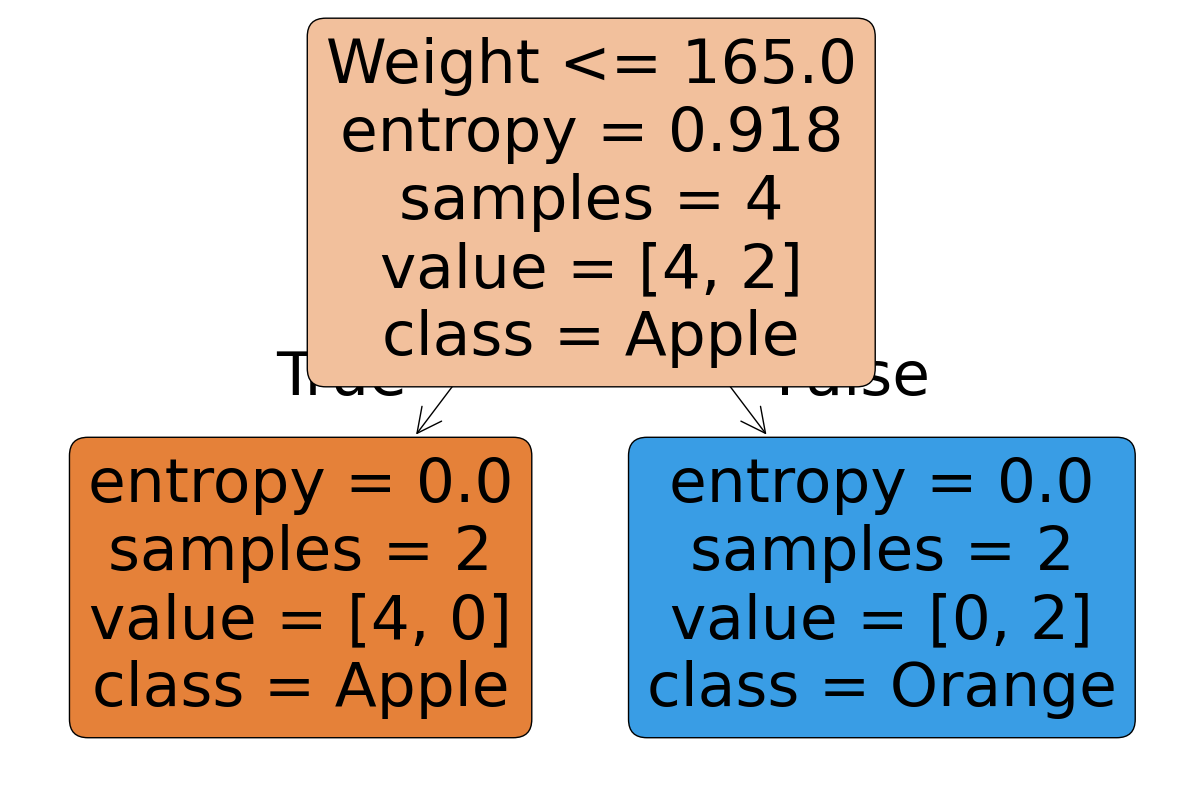

In [71]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Pick the very first tree (index 0) from your forest
chosen_tree = model.estimators_[0]

plt.figure(figsize=(15, 10))
plot_tree(chosen_tree, 
          feature_names=['Weight', 'Texture', 'Color'], 
          class_names=['Apple', 'Orange'], 
          filled=True, 
          rounded=True)
plt.show()

### Let’s apply that "Sampling" logic specifically to our Fruit Dataset (Apple vs. Orange).

To keep it simple, let's say our original dataset has 6 rows and 3 features (Weight, Texture, Color).

### 1. The Rows (Sampling with Replacement)
When you build Tree #1, the algorithm pulls 6 rows from the "hat" one by one, putting them back each time.

#### Your sample for Tree #1 might look like this:
- Row 2 (Orange)
- Row 5 (Apple)
- Row 2 (Orange) — A Repeat!
- Row 1 (Apple)
- Row 6 (Orange)
- Row 2 (Orange) — Another Repeat!
#### What happened here?
- Tree #1 is now "obsessed" with Row 2. It thinks Row 2 is the most important data in the world.
- Rows 3 and 4 were never picked. They are Out-of-Bag.
- Tree #2 will do this again and get a completely different mix.

### 2. The Features (The sqrt(n) Rule)

**We have 3 features:** Weight, Texture, and Color.

The square root of 3 is roughly 1.73, so the algorithm will round and pick 1 or 2 features to look at for each branch.

### How Tree #1 grows:
**Step 1:** The tree wants to make its first split. Instead of looking at all three features, it's "blindfolded" and forced to choose from only Weight and Color. It decides Color is the best split.

**Step 2:** For the next branch, it's blindfolded again and can only see Texture. It has to make a decision based only on Texture.

### 3. Putting it all together
Because of these two steps, here is how your "Forest" of 3 trees looks:

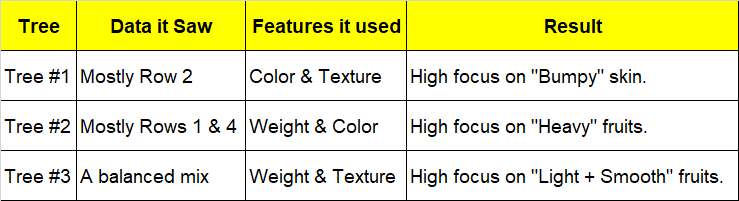

### 🗳️ The Final Prediction
Now, you bring a new fruit: 155g, Smooth, Green.

**Tree #1 (The Color expert) says:** "Green? That's an Apple."

**Tree #2 (The Weight expert) says:** "155g? That's a bit light, likely an Apple."

**Tree #3 (The Texture expert) says:** "Smooth? Definitely an Apple."

**Final Result:** 3 votes for Apple, 0 for Orange. The Forest predicts Apple.

### Why did we go through all that trouble?

If Row 2 was a "weird" fruit (like a super heavy Apple that looks like an Orange), a single tree would be fooled by it. But in a Random Forest, only the trees that happened to pick Row 2 will be fooled. The other 90+ trees will still see the "normal" data and out-vote the mistake!

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [50]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [52]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [54]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [56]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(x_train, y_train)
y_pred = rf_classifier.predict(x_test)
print(y_pred)

[0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 1 0
 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


In [57]:
accuracy = accuracy_score(y_test, y_pred)
# classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
# print("\nClassification Report:\n", classification_rep)

Accuracy: 0.72


In [60]:
sample = x_test.iloc[0:1]
print(sample)
prediction = rf_classifier.predict(sample)
sample_dict = sample.iloc[0].to_dict()
print()
print(f"Sample Patient: {sample_dict}")
print(f"Predicted Diabetes: {'Positive' if prediction[0] == 1 else 'Negative'}")

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668            6       98             58             33      190  34.0   

     DiabetesPedigreeFunction  Age  
668                      0.43   43  

Sample Patient: {'Pregnancies': 6.0, 'Glucose': 98.0, 'BloodPressure': 58.0, 'SkinThickness': 33.0, 'Insulin': 190.0, 'BMI': 34.0, 'DiabetesPedigreeFunction': 0.43, 'Age': 43.0}
Predicted Diabetes: Negative


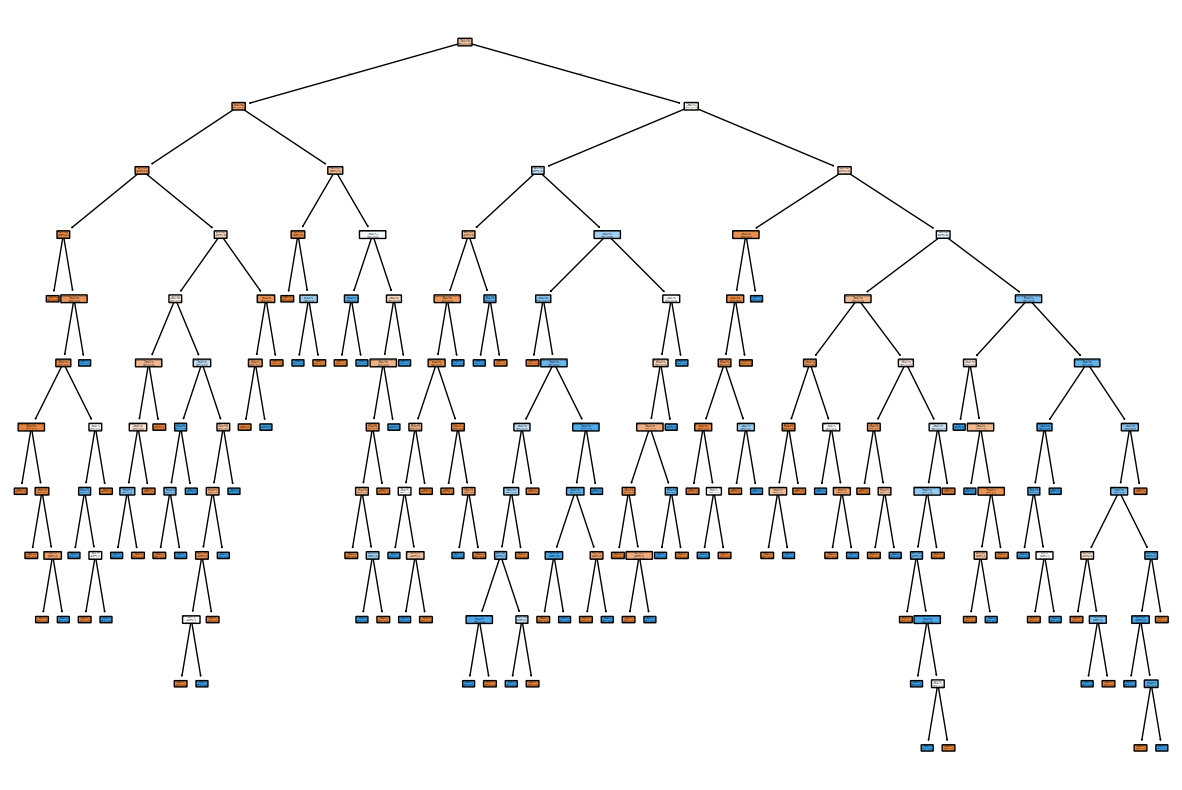

In [64]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Pick the very first tree (index 0) from your forest
chosen_tree = rf_classifier.estimators_[0]

plt.figure(figsize=(15, 10))
plot_tree(chosen_tree, 
          feature_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'], 
          class_names=['Negative', 'Positive'], 
          filled=True, 
          rounded=True)
plt.show()

In [61]:
x.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')